In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "python")))
import partition_function as pf
import ell_to_tau as et
import importlib
importlib.reload(pf)
importlib.reload(et)
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

In [58]:
k=3
L=54*k
l1=7*L
l2=9*k
f = et.make_cyl_eqn(L=54*k, l1=7*k, l2=9*k)
f2 = et.make_cyl_eqn_improved(L=54*k, l1=7*k, l2=9*k)

a = np.exp(2j*np.pi*l1/L)
b = np.exp(2j*np.pi*(L/2)/L)

c = np.exp(2j*np.pi*(l1+l2)/L)
d = np.exp(2j*np.pi*(L/2+l1)/L)

Iab = et.integrate_f2_times_z_between(f, a, b)
Icd = et.integrate_f2_times_z_between(f, c, d)

In [ ]:
np.real(Iab*Icd)

In [2]:
def data1_log(k_start: int = 1, k_end: int = 40, k_step: int = 2):
    """
    Python analogue of:

    data1 = Table[
      Module[{numDet, denDet, rhsNum, rhsDen},
        numDet = combinedDet2[3(k+1), (k+1), 9(k+1)];
        denDet = combinedDet2[5(k+1), 7(k+1), (k+1)];
        rhsNum = computeRHS[3k, k, 9k, Round[3k/2], Round[k/2], Round[9k/2]];
        rhsDen = computeRHS[5k,7k,k, Round[5k/2],Round[7k/2],Round[k/2]];
        {
          numDet[[1]]/denDet[[1]],
          numDet[[2]]/denDet[[2]],
          rhsNum[[1]]/rhsDen[[1]],
          rhsNum[[2]]/rhsDen[[2]],
          rhsNum[[3]]/rhsDen[[3]],
          Exp[3/2*rhsNum[[4]]]/Exp[3/2*rhsDen[[4]]],
          rhsNum[[5]]/rhsDen[[5]],
          rhsNum[[6]],
          rhsNum[[7]]
        }
      ],
      {k,1,30,2}
    ];

    Here combined_det2_log returns (log_bdet, log_pdet).
    """
    rows = []
    k_vals = list(range(k_start, k_end + 1, k_step))

    for k in k_vals:
        kp1 = k + 1

        # ----- determinant side in log-space -----
        # numDet = combinedDet2[3(k+1), (k+1), 9(k+1)]
        log_num_b, log_num_p = pf.combined_det2_log(13 * 2*kp1, 3 * kp1, 1 * kp1)

        # denDet = combinedDet2[5(k+1), 7(k+1), (k+1)]
        log_den_b, log_den_p = pf.combined_det2_log(13 * 2*kp1, 5 * kp1, 7* kp1)

        # ratios
        bdet_ratio = mp.e ** (log_num_b - log_den_b)
        pdet_ratio = mp.e ** (log_num_p - log_den_p)

        # ----- RHS side -----
        # rhsNum = computeRHS[3k,k,9k, Round[3k/2], Round[k/2], Round[9k/2]]
        L_num = 2 * (3*k + 1*k + 9*k)  # = 26k
        rhs_num = et.compute_rhs(
            L=L_num, l1=3*k, l2=1*k)

        # rhsDen = computeRHS[5k,7k,k, Round[5k/2], Round[7k/2], Round[k/2]]
        L_den = 2 * (5*k + 7*k + 1*k)  # = 26k
        rhs_den = et.compute_rhs(
            L=L_den, l1=5*k, l2=7*k )

        # unpack (Python indices)
        f0_num, eta_num, im_num, b_num, jac_num, tau_num, per1_num = rhs_num
        f0_den, eta_den, im_den, b_den, jac_den, tau_den, per1_den = rhs_den
        # Mathematica requested outputs:
        # rhsNum[[1]]/rhsDen[[1]] = fZero^{-2} ratio
        f0_ratio  = f0_num / f0_den

        # rhsNum[[2]]/rhsDen[[2]] = eta ratio
        eta_ratio = eta_num / eta_den

        # rhsNum[[3]]/rhsDen[[3]] = Im(tau) ratio
        im_ratio  = im_num / im_den
        # Exp[3/2*rhsNum[[4]]]/Exp[3/2*rhsDen[[4]]] = exp(3/2*(b_num-b_den))
        bexp_ratio = mp.e ** (mp.mpf("1.5") * (mp.mpf(b_num) - mp.mpf(b_den)))

        # rhsNum[[5]]/rhsDen[[5]] = jacobian ratio
        jac_ratio = jac_num / jac_den

        # rhsNum[[6]] = tau_num
        # rhsNum[[7]] = per1_num

        row = [
            complex(bdet_ratio),     # numDet[[1]]/denDet[[1]]
            complex(pdet_ratio),     # numDet[[2]]/denDet[[2]]
            complex(f0_ratio),       # rhsNum[[1]]/rhsDen[[1]]
            complex(eta_ratio),      # rhsNum[[2]]/rhsDen[[2]]
            complex(im_ratio),       # rhsNum[[3]]/rhsDen[[3]]
            complex(bexp_ratio),     # exp(3/2*(b_num-b_den))
            complex(jac_ratio),      # rhsNum[[5]]/rhsDen[[5]]
            complex(tau_num),        # rhsNum[[6]]
            complex(per1_num),       # rhsNum[[7]]
        ]
        rows.append(row)

    return np.array(k_vals, dtype=int), np.array(rows, dtype=np.complex128)

In [111]:
def data2_log(k_start: int = 1, k_end: int = 30, k_step: int = 2):
    """
    Python analogue of:

    data1 = Table[
      Module[{numDet, denDet, rhsNum, rhsDen},
        numDet = combinedDet2[3(k+1), (k+1), 9(k+1)];
        denDet = combinedDet2[5(k+1), 7(k+1), (k+1)];
        rhsNum = computeRHS[3k, k, 9k, Round[3k/2], Round[k/2], Round[9k/2]];
        rhsDen = computeRHS[5k,7k,k, Round[5k/2],Round[7k/2],Round[k/2]];
        {
          numDet[[1]]/denDet[[1]],
          numDet[[2]]/denDet[[2]],
          rhsNum[[1]]/rhsDen[[1]],
          rhsNum[[2]]/rhsDen[[2]],
          rhsNum[[3]]/rhsDen[[3]],
          Exp[3/2*rhsNum[[4]]]/Exp[3/2*rhsDen[[4]]],
          rhsNum[[5]]/rhsDen[[5]],
          rhsNum[[6]],
          rhsNum[[7]]
        }
      ],
      {k,1,30,2}
    ];

    Here combined_det2_log returns (log_bdet, log_pdet).
    """
    all_rows = []
    k_vals = list(range(k_start, 19, 1))
    l_vals = list(range(1, 6))
    for l in l_vals:
        rows_for_l = []
        for k in k_vals:
            kp1 = k + 1

            # ----- determinant side in log-space -----
            # numDet = combinedDet2[3(k+1), (k+1), 9(k+1)]
            log_num_b, log_num_p = pf.combined_det2_log(2 * (154)*l, (2+4*k)*l, (2+4*k)*l)

            # denDet = combinedDet2[5(k+1), 7(k+1), (k+1)]
            #log_den_b, log_den_p = pf.combined_det2_log(13 * 2*kp1, 5 * kp1, 7* kp1)

            # ratios
            #bdet_ratio = mp.e ** (log_num_b - log_den_b)
          #  pdet_ratio = mp.e ** (log_num_p - log_den_p)

            # ----- RHS side -----
            # rhsNum = computeRHS[3k,k,9k, Round[3k/2], Round[k/2], Round[9k/2]]
            L_num = 2 * (154)*l  # = 26k
            rhs_num = et.compute_rhs(
                L=2 * (154)*l, l1=(2+4*k)*l, l2=(2+4*k)*l)

            # rhsDen = computeRHS[5k,7k,k, Round[5k/2], Round[7k/2], Round[k/2]]
            L_den = 2 * (5*k + 7*k + 1*k)  # = 26k
           # rhs_den = et.compute_rhs(
           #     L=L_den, l1=5*k, l2=7*k )

            # unpack (Python indices)
            f0_num, eta_num, im_num, b_num, jac_num, tau_num, per1_num = rhs_num
          #  f0_den, eta_den, im_den, b_den, jac_den, tau_den, per1_den = rhs_den
            # Mathematica requested outputs:
            # rhsNum[[1]]/rhsDen[[1]] = fZero^{-2} ratio
           # f0_ratio  = f0_num / f0_den

            # rhsNum[[2]]/rhsDen[[2]] = eta ratio
           # eta_ratio = eta_num / eta_den

            # rhsNum[[3]]/rhsDen[[3]] = Im(tau) ratio
           # im_ratio  = im_num / im_den
            # Exp[3/2*rhsNum[[4]]]/Exp[3/2*rhsDen[[4]]] = exp(3/2*(b_num-b_den))
          #  bexp_ratio = mp.e ** (mp.mpf("1.5") * (mp.mpf(b_num) - mp.mpf(b_den)))

            # rhsNum[[5]]/rhsDen[[5]] = jacobian ratio
         #   jac_ratio = jac_num / jac_den

            # rhsNum[[6]] = tau_num
            # rhsNum[[7]] = per1_num

            row = [
                complex(mp.e**(log_num_b)),     # numDet[[1]]/denDet[[1]]
                complex(mp.e**(log_num_p)),     # numDet[[2]]/denDet[[2]]
                complex(f0_num),       # rhsNum[[1]]/rhsDen[[1]]
                complex(eta_num),      # rhsNum[[2]]/rhsDen[[2]]
                complex(im_num),       # rhsNum[[3]]/rhsDen[[3]]
                complex(b_num),     # b_num
                complex(jac_num),      # rhsNum[[5]]/rhsDen[[5]]
                complex(tau_num),        # rhsNum[[6]]
                complex(per1_num),       # rhsNum[[7]]
            ]
            rows_for_l.append(row)
        all_rows.append(rows_for_l)

    data_3d = np.array(all_rows, dtype=np.complex128)
    return np.array(l_vals, dtype=int), np.array(k_vals, dtype=int), data_3d

In [85]:
#order of outputs is bdet, pdet, f(0), eta, im(tau), exp(b), jacobian, tau, per[1]
kvals,data1=data1_log()

In [160]:
kp1 = 21
n = 2
et.theta3_eta_sqrt(13 * 2 * kp1, 3 * kp1, 1 * kp1, n=n)

mpc(real='1.1605362341968994875410541994432576154556653509044898', imag='0.25497651941170072728091025483794775482700618206520109')

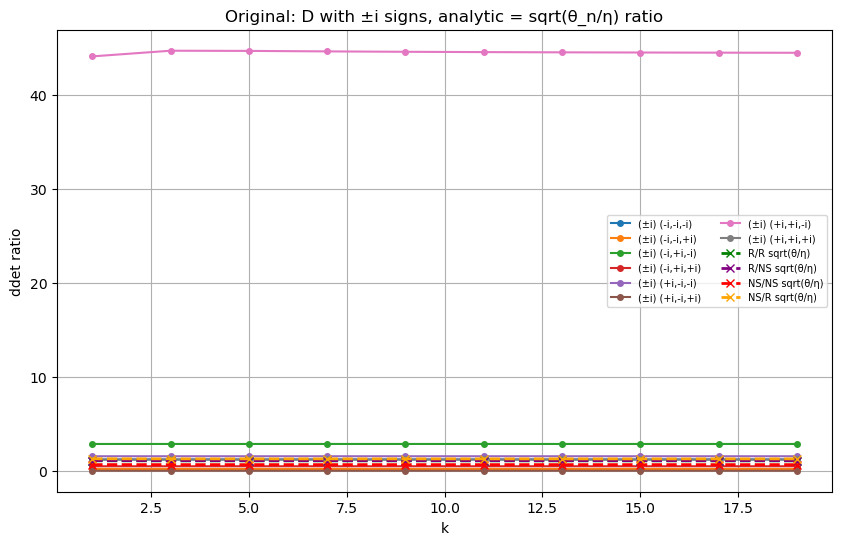

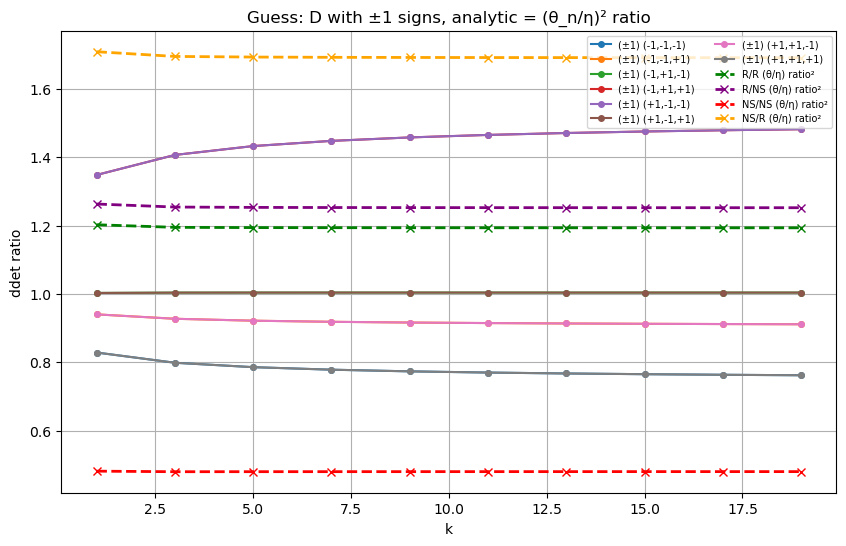

In [ ]:
from itertools import product

def ddet_log_plot(k_start=1, k_end=20, k_step=2):
    k_vals = list(range(k_start, k_end + 1, k_step))
    sign_combos = list(product([False, True], repeat=3))

    # Numerical ratios: original (±i) and guess (±1)
    orig_ratios = {s: [] for s in sign_combos}
    guess_ratios = {s: [] for s in sign_combos}
    for k in k_vals:
        kp1 = k + 1
        for s in sign_combos:
            log_num = pf.ddet_log(13 * 2 * kp1, 3 * kp1, 1 * kp1, signs=s)
            log_den = pf.ddet_log(13 * 2 * kp1, 5 * kp1, 7 * kp1, signs=s)
            orig_ratios[s].append(float(mp.e ** (log_num - log_den)))

            log_num_g = pf.ddet_log_guess(13 * 2 * kp1, 3 * kp1, 1 * kp1, signs=s)
            log_den_g = pf.ddet_log_guess(13 * 2 * kp1, 5 * kp1, 7 * kp1, signs=s)
            guess_ratios[s].append(float(mp.e ** (log_num_g - log_den_g)))

    # Analytic: original sqrt(θ/η) and guess (θ/η) (squared ratio)
    spin_labels = {1: "R/R", 2: "R/NS", 3: "NS/NS", 4: "NS/R"}
    spin_colors = {1: "green", 2: "purple", 3: "red", 4: "orange"}
    analytic_orig = {n: [] for n in [1, 2, 3, 4]}
    analytic_guess = {n: [] for n in [1, 2, 3, 4]}
    for k in k_vals:
        kp1 = k + 1
        f_num = et.make_cyl_eqn_improved(13 * 2 * kp1, 3 * kp1, 1 * kp1)
        f_den = et.make_cyl_eqn_improved(13 * 2 * kp1, 5 * kp1, 7 * kp1)
        b_num = et.pole_intercept_average(f_num, 13 * 2 * kp1, 3 * kp1, 1 * kp1)
        b_den = et.pole_intercept_average(f_den, 13 * 2 * kp1, 5 * kp1, 7 * kp1)
        bcorr = float(mp.e ** ((mp.mpf("1.5") * (mp.mpf(b_num) - mp.mpf(b_den))) / mp.mpf("36")))
        for n in [1, 2, 3, 4]:
            a_num = et.theta3_eta_sqrt(13 * 2 * kp1, 3 * kp1, 1 * kp1, n=n)
            a_den = et.theta3_eta_sqrt(13 * 2 * kp1, 5 * kp1, 7 * kp1, n=n)
            analytic_orig[n].append(float(abs(a_num / a_den)) * bcorr)
            analytic_guess[n].append(float(abs((a_num / a_den) )** 2) * bcorr)

    # --- Plot 1: original ddet (±i) + original analytic ---
    plt.figure(figsize=(10, 6))
    cmap = plt.cm.tab10
    for idx, s in enumerate(sign_combos):
        label = "(±i) " + "(" + ",".join("+i" if b else "-i" for b in s) + ")"
        plt.plot(k_vals, orig_ratios[s], marker="o", linestyle="-", color=cmap(idx), label=label, markersize=4)
    for n in [1, 2, 3, 4]:
        plt.plot(k_vals, analytic_orig[n], marker="x", linestyle="--", color=spin_colors[n], label=f"{spin_labels[n]} sqrt(θ/η)", linewidth=2)
    plt.xlabel("k")
    plt.ylabel("ddet ratio")
    plt.title("Original: D with ±i signs, analytic = sqrt(θ_n/η) ratio")
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True)
    plt.show()

    # --- Plot 2: guess ddet (±1) + guess analytic (squared) ---
    plt.figure(figsize=(10, 6))
    for idx, s in enumerate(sign_combos):
        label = "(±i) " + "(" + ",".join("+i" if b else "-i" for b in s) + ")"
        plt.plot(k_vals, guess_ratios[s], marker="o", linestyle="-", color=cmap(idx), label=label, markersize=4)
    for n in [1, 2, 3, 4]:
        plt.plot(k_vals, analytic_guess[n], marker="x", linestyle="--", color=spin_colors[n], label=f"{spin_labels[n]} (θ/η) ratio²", linewidth=2)
    plt.xlabel("k")
    plt.ylabel("ddet ratio")
    #plt.title("Guess: D with ±1 signs, analytic = (θ_n/η)² ratio")
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True)
    plt.show()

    return np.array(k_vals), orig_ratios, guess_ratios, analytic_orig, analytic_guess

kvals_d, orig, guess, ana_orig, ana_guess = ddet_log_plot()

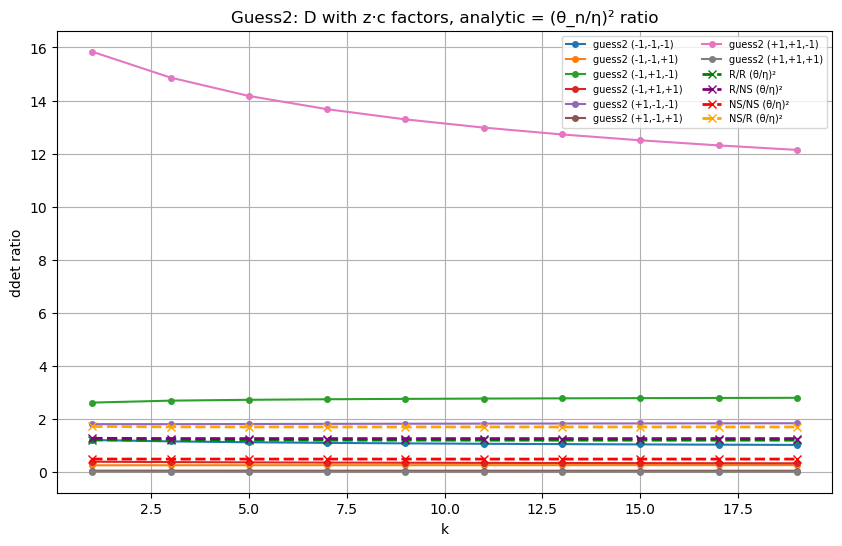

In [6]:
def ddet_log_guess2_plot(k_start=1, k_end=20, k_step=2):
    """Test ddet_log_guess2 (with geometric factors z_n*c_n) against analytic formula."""
    k_vals = list(range(k_start, k_end + 1, k_step))
    sign_combos = list(product([False, True], repeat=3))

    # Numerical ratios using ddet_log_guess2
    guess2_ratios = {s: [] for s in sign_combos}
    for k in k_vals:
        kp1 = k + 1
        for s in sign_combos:
            log_num = pf.ddet_log_guess2(13 * 2 * kp1, 3 * kp1, 1 * kp1, signs=s)
            log_den = pf.ddet_log_guess2(13 * 2 * kp1, 5 * kp1, 7 * kp1, signs=s)
            guess2_ratios[s].append(float(mp.e ** (log_num - log_den)))

    # Analytic: (θ_n/η)² (squared ratio)
    spin_labels = {1: "R/R", 2: "R/NS", 3: "NS/NS", 4: "NS/R"}
    spin_colors = {1: "green", 2: "purple", 3: "red", 4: "orange"}
    analytic = {n: [] for n in [1, 2, 3, 4]}
    for k in k_vals:
        kp1 = k + 1
        f_num = et.make_cyl_eqn_improved(13 * 2 * kp1, 3 * kp1, 1 * kp1)
        f_den = et.make_cyl_eqn_improved(13 * 2 * kp1, 5 * kp1, 7 * kp1)
        b_num = et.pole_intercept_average(f_num, 13 * 2 * kp1, 3 * kp1, 1 * kp1)
        b_den = et.pole_intercept_average(f_den, 13 * 2 * kp1, 5 * kp1, 7 * kp1)
        bcorr = float(mp.e ** ((mp.mpf("1.5") * (mp.mpf(b_num) - mp.mpf(b_den))) / mp.mpf("36")))
        for n in [1, 2, 3, 4]:
            a_num = et.theta3_eta_sqrt(13 * 2 * kp1, 3 * kp1, 1 * kp1, n=n)
            a_den = et.theta3_eta_sqrt(13 * 2 * kp1, 5 * kp1, 7 * kp1, n=n)
            analytic[n].append(float((a_num / a_den) ** 2) * bcorr)

    # Plot
    plt.figure(figsize=(10, 6))
    cmap = plt.cm.tab10
    for idx, s in enumerate(sign_combos):
        label = "guess2 " + "(" + ",".join("+1" if b else "-1" for b in s) + ")"
        plt.plot(k_vals, guess2_ratios[s], marker="o", linestyle="-", color=cmap(idx), label=label, markersize=4)
    for n in [1, 2, 3, 4]:
        plt.plot(k_vals, analytic[n], marker="x", linestyle="--", color=spin_colors[n], label=f"{spin_labels[n]} (θ/η)²", linewidth=2)
    plt.xlabel("k")
    plt.ylabel("ddet ratio")
    plt.title("Guess2: D with z·c factors, analytic = (θ_n/η)² ratio")
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True)
    #plt.ylim([0.5,2])
    plt.show()
    return np.array(k_vals), guess2_ratios, analytic

kvals_g2, guess2_ratios, ana_g2 = ddet_log_guess2_plot()

In [144]:
thetaTest = et.theta3_eta_sqrt(int(2*3003),1001,1001)

In [148]:
tau = 0.5+0.5j
n = 3
tau_mp = mp.mpc(tau)
nome = mp.exp(mp.pi * 1j * tau_mp)
theta_n = mp.jtheta(n, 0, nome)
eta = mp.mpc(et.dedekind_eta(tau))
print(mp.sqrt(theta_n/eta))

(1.0811782878393746945684219080230068769581589412324 + 0.14233982193131805357053116108938178637758346983997j)


In [112]:
lvals, kvals, data2 = data2_log()

In [ ]:
#order of outputs is bdet (0), pdet (1), f(0) (2), eta (3), im(tau) (4), exp(b) (5), jacobian (6), tau (7), per(1) (8)

In [100]:
len(data2)

5

In [110]:
kvals

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

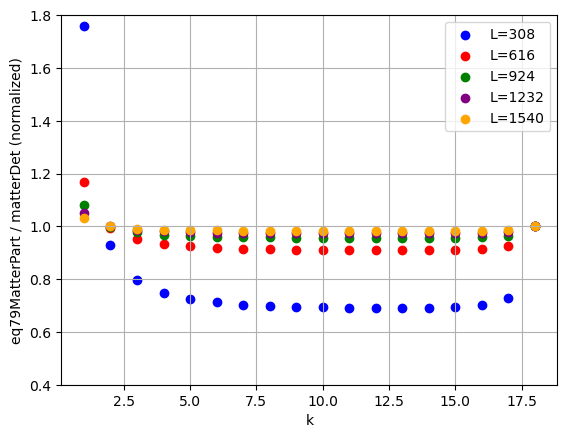

In [116]:
colors = ['blue', 'red', 'green',"purple","orange"]
plt.figure()
lv = lvals[0]
for i in range(0,5):
    d = data2[i]  # shape (len(kvals), 9)
    bvalsRatio = []
    for j in range(0,len(d[:,5])):
        bvalsRatio.append(complex(mp.e ** (mp.mpf("1.5") * (mp.mpf(float(d[j,5].real)) - mp.mpf(float(d[-1,5].real))))))
    bvalsRatio = np.array(bvalsRatio)
    eq79MatterPart = (np.abs(d[:, 4]) ** (-13.0)) * \
                     (np.abs(d[:, 3]) ** (-52.0)) * \
                     (bvalsRatio ** (26.0/18.0))
    matterDet = d[:, 1]
    ratio = eq79MatterPart / matterDet
    normalized = ratio / ratio[-1]
    plt.scatter(kvals, np.real(normalized), color=colors[i], label=f'L={int(2 * (154)*(i+1))}')
plt.xlabel("k")
plt.ylabel("eq79MatterPart / matterDet (normalized)")
plt.legend()
plt.grid(True)
plt.ylim([0.4,1.8])
plt.show()

In [ ]:


# Mathematica is 1-indexed; Python is 0-indexed:
# data1[[All,5]] -> data1[:,4]
# data1[[All,4]] -> data1[:,3]
# data1[[All,6]] -> data1[:,5]

eq79MatterPart = (np.abs(data1[:, 4]) ** (-13.0)) * \
             (np.abs(data1[:, 3]) ** (-52.0)) * \
             (data1[:, 5] ** (26.0/18.0))

# If you want a real-valued plot, plot the magnitude or real part:
y = np.real(eq79MatterPart)   # or np.abs(eq79Guess1)
matterDet = data1[:,1]
y2 = np.real(matterDet)

plt.figure()
plt.plot(kvals, y, marker="o", linestyle="-")
plt.plot(kvals, y2, marker="o", linestyle="-",color="orange")
plt.xlabel("k")
plt.ylabel("eq79Guess1 (real part)")
plt.title("eq79Guess1 vs k")
plt.grid(True)
plt.ylim({2.8,3.7})
plt.show()

In [63]:
ftest2(np.exp(1j*2*np.pi/L))

(np.complex128(3.3418360568034697+0.11393520273524291j),
 np.complex128(1.2442229662813507+0.07756165885754969j))

In [64]:
ftest(np.exp(1j*2*np.pi/L))

np.complex128(7.087389219036471+0.547558185500666j)

In [67]:
fvalues = []
fvalues2 = []
for i in range(2,40):
    L = 13*2*i
    l1 = 3*i
    l2 = 1*i
    ftest = et.make_cyl_eqn(L=L, l1=l1, l2=l2)
    ftest2 = et.make_cyl_eqn_improved(L=L, l1=l1, l2=l2)
    fvalues.append(ftest(np.exp(1j*2*np.pi/L)))
    fvalues2.append(ftest2(np.exp(1j*2*np.pi/L)))

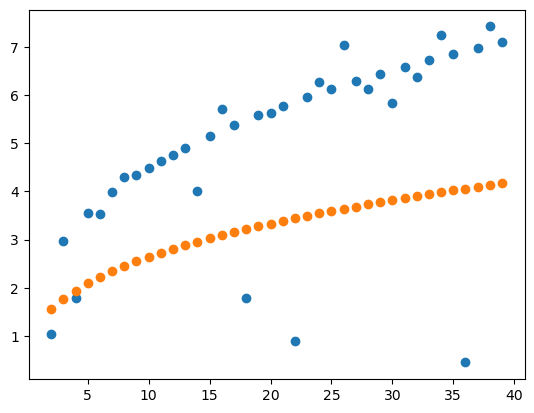

In [68]:
plt.scatter(np.arange(2,40),np.abs(fvalues))
plt.scatter(np.arange(2,40),np.abs(fvalues2))

In [118]:
len(data1)

20

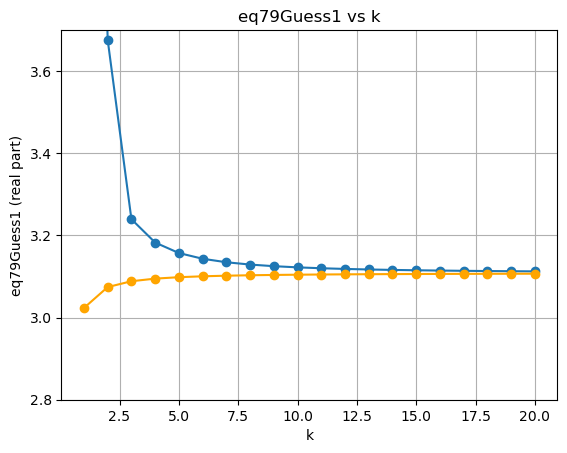

In [86]:


# Mathematica is 1-indexed; Python is 0-indexed:
# data1[[All,5]] -> data1[:,4]
# data1[[All,4]] -> data1[:,3]
# data1[[All,6]] -> data1[:,5]
kvals = np.arange(1,21)

eq79MatterPart = (np.abs(data1[:, 4]) ** (-13.0)) * \
             (np.abs(data1[:, 3]) ** (-52.0)) * \
             (data1[:, 5] ** (26.0/18.0))

# If you want a real-valued plot, plot the magnitude or real part:
y = np.real(eq79MatterPart)   # or np.abs(eq79Guess1)
matterDet = data1[:,1]
y2 = np.real(matterDet)

plt.figure()
plt.plot(kvals, y, marker="o", linestyle="-")
plt.plot(kvals, y2, marker="o", linestyle="-",color="orange")
plt.xlabel("k")
plt.ylabel("eq79Guess1 (real part)")
plt.title("eq79Guess1 vs k")
plt.grid(True)
plt.ylim({2.8,3.7})
plt.show()

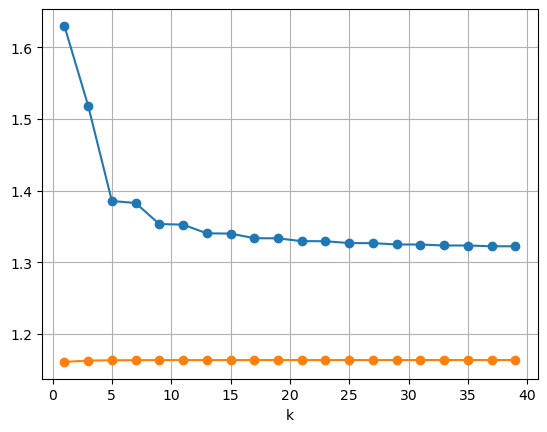

In [ ]:
#order of outputs is bdet (0), pdet (1), f(0) (2), eta (3), im(tau) (4), exp(b) (5), jacobian (6), tau (7), per(1) (8)

# k values corresponding to your rows (e.g. k = 1,3,5,...,19)
kVals = np.arange(1, 40, 2)

#eq79CompareBCghost is what the bc-ghost part of equation 7.9 should be

bdet = data1[:,0]

eq79CompareBCghost = (
    data1[:, 2] *                
    data1[:, 6] *     
    (np.abs(data1[:, 3]) ** (4))
)

# Plot real part (or magnitude if you prefer)
y = np.real(eq79CompareBCghost)   # or np.abs(eq79Actual3)

plt.figure()
plt.plot(kVals, y, marker="o", linestyle="-", label="")
plt.plot(kVals, bdet, marker="o", linestyle="-", label="")
plt.xlabel("k")
plt.grid(True)
plt.show()

My goal is to construct arbitrary genus bosonic string amplitudes using kontsevich's ribbon graph decomposition of the moduli space. Right now, I've been able to successfully reproduce the genus-1 matter partition function, as you can see in testing2.ipynb, but am struggling to reproduce either the free fermion (with any boundary conditions of NS/R combinations) or b-c ghost. Right now, I'm focusing on the free fermion. I've attached a note (a .pdf file, also present in the repository you have access to as a .tex file). For the case of the matter partition function, the logic is worked out in section 5, with the exact correspondence to the Kontsevich ribbon graph and disc frame being given in section 2. My guess for how the fermion works out is given in section 8 ("free fermion"). Meanwhile, in testing2.ipynb, the exact correspondence between the numerical and analytic matter calculations is worked out in the plot with title "plt.title("eq79Guess1 vs k")". The guess for how the free fermion should work out (comparing analytic to numerical) is in the function "ddet_log_plot". Now, can you figure out what is going on and how to get the numerical and analytic free fermion cases to match? I'm not sure if the problem is numerical or analytical.